# WC2026 Final, Spain versus Argentina, Comparative Social Network Analysis

This notebook performs a full comparative Social Network Analysis of the
Spain and Argentina pass networks from the World Cup 2026 final. It loads
the edgelist files produced by 01_graph_construction.ipynb and analyzes
both teams side by side throughout every section.

## Section 0, Setup and Data Loading

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import community as community_louvain
import itertools
import os

np.random.seed(42)
plt.style.use('default')
sns.set_theme(style='whitegrid')

SPAIN_COLOR = '#C60B1E'
ARGENTINA_COLOR = '#74ACDF'

print('Libraries imported and plot style set to a white background theme.')

Libraries imported and plot style set to a white background theme.


In [2]:
def load_edgelist(filepath):
    G = nx.DiGraph()
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                parts = line.split(' ')
                source_raw, target_raw, weight_raw, avg_x_source_raw, avg_y_source_raw, avg_x_target_raw, avg_y_target_raw = parts
                source = source_raw.replace('_', ' ')
                target = target_raw.replace('_', ' ')
                weight = int(weight_raw)
                avg_x_source = None if avg_x_source_raw == 'NA' else float(avg_x_source_raw)
                avg_y_source = None if avg_y_source_raw == 'NA' else float(avg_y_source_raw)
                avg_x_target = None if avg_x_target_raw == 'NA' else float(avg_x_target_raw)
                avg_y_target = None if avg_y_target_raw == 'NA' else float(avg_y_target_raw)
                if source not in G.nodes:
                    G.add_node(source, avg_x=avg_x_source, avg_y=avg_y_source)
                if target not in G.nodes:
                    G.add_node(target, avg_x=avg_x_target, avg_y=avg_y_target)
                G.add_edge(source, target, weight=weight)
    except Exception as e:
        print('Failed to load edgelist file', filepath, ':', e)
        raise
    return G

In [3]:
G_spain = load_edgelist('../data/clean/spain_passes.edgelist')
G_argentina = load_edgelist('../data/clean/argentina_passes.edgelist')

G_spain_p1 = load_edgelist('../data/clean/spain_phase1_firsthalf.edgelist')
G_spain_p2 = load_edgelist('../data/clean/spain_phase2_before_red.edgelist')
G_spain_p3 = load_edgelist('../data/clean/spain_phase3_after_red.edgelist')
G_spain_p4 = load_edgelist('../data/clean/spain_phase4_extratime.edgelist')

G_arg_p1 = load_edgelist('../data/clean/argentina_phase1_firsthalf.edgelist')
G_arg_p2 = load_edgelist('../data/clean/argentina_phase2_before_red.edgelist')
G_arg_p3 = load_edgelist('../data/clean/argentina_phase3_after_red.edgelist')
G_arg_p4 = load_edgelist('../data/clean/argentina_phase4_extratime.edgelist')

print('All edgelist files loaded successfully.')

All edgelist files loaded successfully.


G_arg_p3 is empty because Argentina had no completed passes recorded in
the window immediately after Enzo Fernandez received the red card at
expandedMinute 97, before extra time began.

In [4]:
RED_CARD_MINUTE = 97

def graph_total_weight(G):
    return sum(data['weight'] for _, _, data in G.edges(data=True))

loading_summary = pd.DataFrame([
    {'Graph': 'G_spain', 'Nodes': G_spain.number_of_nodes(), 'Edges': G_spain.number_of_edges(), 'Total weight': graph_total_weight(G_spain)},
    {'Graph': 'G_argentina', 'Nodes': G_argentina.number_of_nodes(), 'Edges': G_argentina.number_of_edges(), 'Total weight': graph_total_weight(G_argentina)},
    {'Graph': 'G_spain_p1', 'Nodes': G_spain_p1.number_of_nodes(), 'Edges': G_spain_p1.number_of_edges(), 'Total weight': graph_total_weight(G_spain_p1)},
    {'Graph': 'G_spain_p2', 'Nodes': G_spain_p2.number_of_nodes(), 'Edges': G_spain_p2.number_of_edges(), 'Total weight': graph_total_weight(G_spain_p2)},
    {'Graph': 'G_spain_p3', 'Nodes': G_spain_p3.number_of_nodes(), 'Edges': G_spain_p3.number_of_edges(), 'Total weight': graph_total_weight(G_spain_p3)},
    {'Graph': 'G_spain_p4', 'Nodes': G_spain_p4.number_of_nodes(), 'Edges': G_spain_p4.number_of_edges(), 'Total weight': graph_total_weight(G_spain_p4)},
    {'Graph': 'G_arg_p1', 'Nodes': G_arg_p1.number_of_nodes(), 'Edges': G_arg_p1.number_of_edges(), 'Total weight': graph_total_weight(G_arg_p1)},
    {'Graph': 'G_arg_p2', 'Nodes': G_arg_p2.number_of_nodes(), 'Edges': G_arg_p2.number_of_edges(), 'Total weight': graph_total_weight(G_arg_p2)},
    {'Graph': 'G_arg_p3', 'Nodes': G_arg_p3.number_of_nodes(), 'Edges': G_arg_p3.number_of_edges(), 'Total weight': graph_total_weight(G_arg_p3)},
    {'Graph': 'G_arg_p4', 'Nodes': G_arg_p4.number_of_nodes(), 'Edges': G_arg_p4.number_of_edges(), 'Total weight': graph_total_weight(G_arg_p4)},
])

print('Loading summary for every graph used in this notebook:')
print(loading_summary.to_string(index=False))

Loading summary for every graph used in this notebook:
      Graph  Nodes  Edges  Total weight
    G_spain     17    163           792
G_argentina     17    147           377
 G_spain_p1     11     79           327
 G_spain_p2     15     94           263
 G_spain_p3      9     13            14
 G_spain_p4     13     77           188
   G_arg_p1     12     66           164
   G_arg_p2     14     75           118
   G_arg_p3      0      0             0
   G_arg_p4     11     50            95


## Section 1, Introduction

This dataset captures the 2026 FIFA World Cup final between Spain and
Argentina, played on July 19, 2026, a match Argentina won. The network
captures completed pass sequences where nodes are players and directed
weighted edges represent the number of times one player passed to another
throughout the match. Argentina received a red card at expandedMinute 97,
Enzo Fernandez, double yellow, meaning they played with 10 men from that
point through the rest of the second half and the entirety of extra time.

### Network classification

Directed, a pass has a sender and a receiver, so directionality carries
real tactical meaning.

Weighted, each edge weight encodes how many times one specific player
passed to another specific player.

Not bipartite, every player both sends and receives passes, so nodes are
not split into two disjoint role based sets.

Not planar, and cyclic, both verified programmatically below.

Small and dense relative to most social networks, 17 nodes per team, since
every outfield player plus substitutes who touched the ball are included.

In [5]:
is_planar_spain, _ = nx.check_planarity(G_spain)
is_planar_argentina, _ = nx.check_planarity(G_argentina)

print('Is G_spain planar:', is_planar_spain)
print('Is G_argentina planar:', is_planar_argentina)

is_dag_spain = nx.is_directed_acyclic_graph(G_spain)
is_dag_argentina = nx.is_directed_acyclic_graph(G_argentina)

print('Is G_spain a directed acyclic graph:', is_dag_spain)
print('Is G_argentina a directed acyclic graph:', is_dag_argentina)
print('Neither graph is a directed acyclic graph, so both passing networks contain cycles, consistent with players regularly passing the ball back and forth.')

Is G_spain planar: False
Is G_argentina planar: False
Is G_spain a directed acyclic graph: False
Is G_argentina a directed acyclic graph: False
Neither graph is a directed acyclic graph, so both passing networks contain cycles, consistent with players regularly passing the ball back and forth.


### Main visualization, pass networks on a football pitch

The helper functions below draw a cartoon football pitch and place each
player at their average touch position, then draw the inferred passes as
curved directed arrows.

In [6]:
def draw_pitch_background(ax):
    pitch = mpatches.Rectangle((0, 0), 100, 100, linewidth=2, edgecolor='white', facecolor='#4a7c3f', zorder=0)
    ax.add_patch(pitch)

    ax.plot([50, 50], [0, 100], color='white', linewidth=2, zorder=1)

    center_circle = mpatches.Circle((50, 50), 9.15, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    ax.add_patch(center_circle)
    ax.plot([50], [50], marker='o', color='white', markersize=3, zorder=1)

    left_penalty_box = mpatches.Rectangle((0, 21.1), 16.5, 57.8, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    right_penalty_box = mpatches.Rectangle((83.5, 21.1), 16.5, 57.8, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    ax.add_patch(left_penalty_box)
    ax.add_patch(right_penalty_box)

    left_goal_box = mpatches.Rectangle((0, 36.8), 5.5, 26.4, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    right_goal_box = mpatches.Rectangle((94.5, 36.8), 5.5, 26.4, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    ax.add_patch(left_goal_box)
    ax.add_patch(right_goal_box)

    corner_radius = 2
    corner_specs = [(0, 0, 0, 90), (0, 100, 270, 360), (100, 0, 90, 180), (100, 100, 180, 270)]
    for cx, cy, theta1, theta2 in corner_specs:
        corner_arc = mpatches.Arc((cx, cy), corner_radius * 2, corner_radius * 2, theta1=theta1, theta2=theta2, edgecolor='white', linewidth=2, zorder=1)
        ax.add_patch(corner_arc)

    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect('equal')
    ax.axis('off')


def scale_edge_width(weight, min_weight, max_weight, min_lw=0.5, max_lw=6.0):
    if max_weight == min_weight:
        return (min_lw + max_lw) / 2.0
    return min_lw + (weight - min_weight) / (max_weight - min_weight) * (max_lw - min_lw)


def draw_curved_edge(ax, x1, y1, x2, y2, width, color, alpha=0.6):
    ax.annotate(
        '',
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='-|>',
            color=color,
            linewidth=width,
            alpha=alpha,
            connectionstyle='arc3,rad=0.2',
            shrinkA=8,
            shrinkB=8
        ),
        zorder=2
    )


def draw_player_label(ax, x, y, name, fontsize=7):
    offsets = [(-0.5, -0.5), (-0.5, 0.5), (0.5, -0.5), (0.5, 0.5), (0.7, 0), (-0.7, 0), (0, 0.7), (0, -0.7)]
    for dx, dy in offsets:
        ax.text(x + dx, y + dy, name, fontsize=fontsize, color='black', ha='center', va='center', zorder=6)
    ax.text(x, y, name, fontsize=fontsize, color='white', ha='center', va='center', zorder=7)


def get_team_color_from_title(title):
    if 'argentina' in title.lower():
        return ARGENTINA_COLOR
    return SPAIN_COLOR


print('Pitch drawing helper functions defined.')

Pitch drawing helper functions defined.


Saved pitch_visualization.png


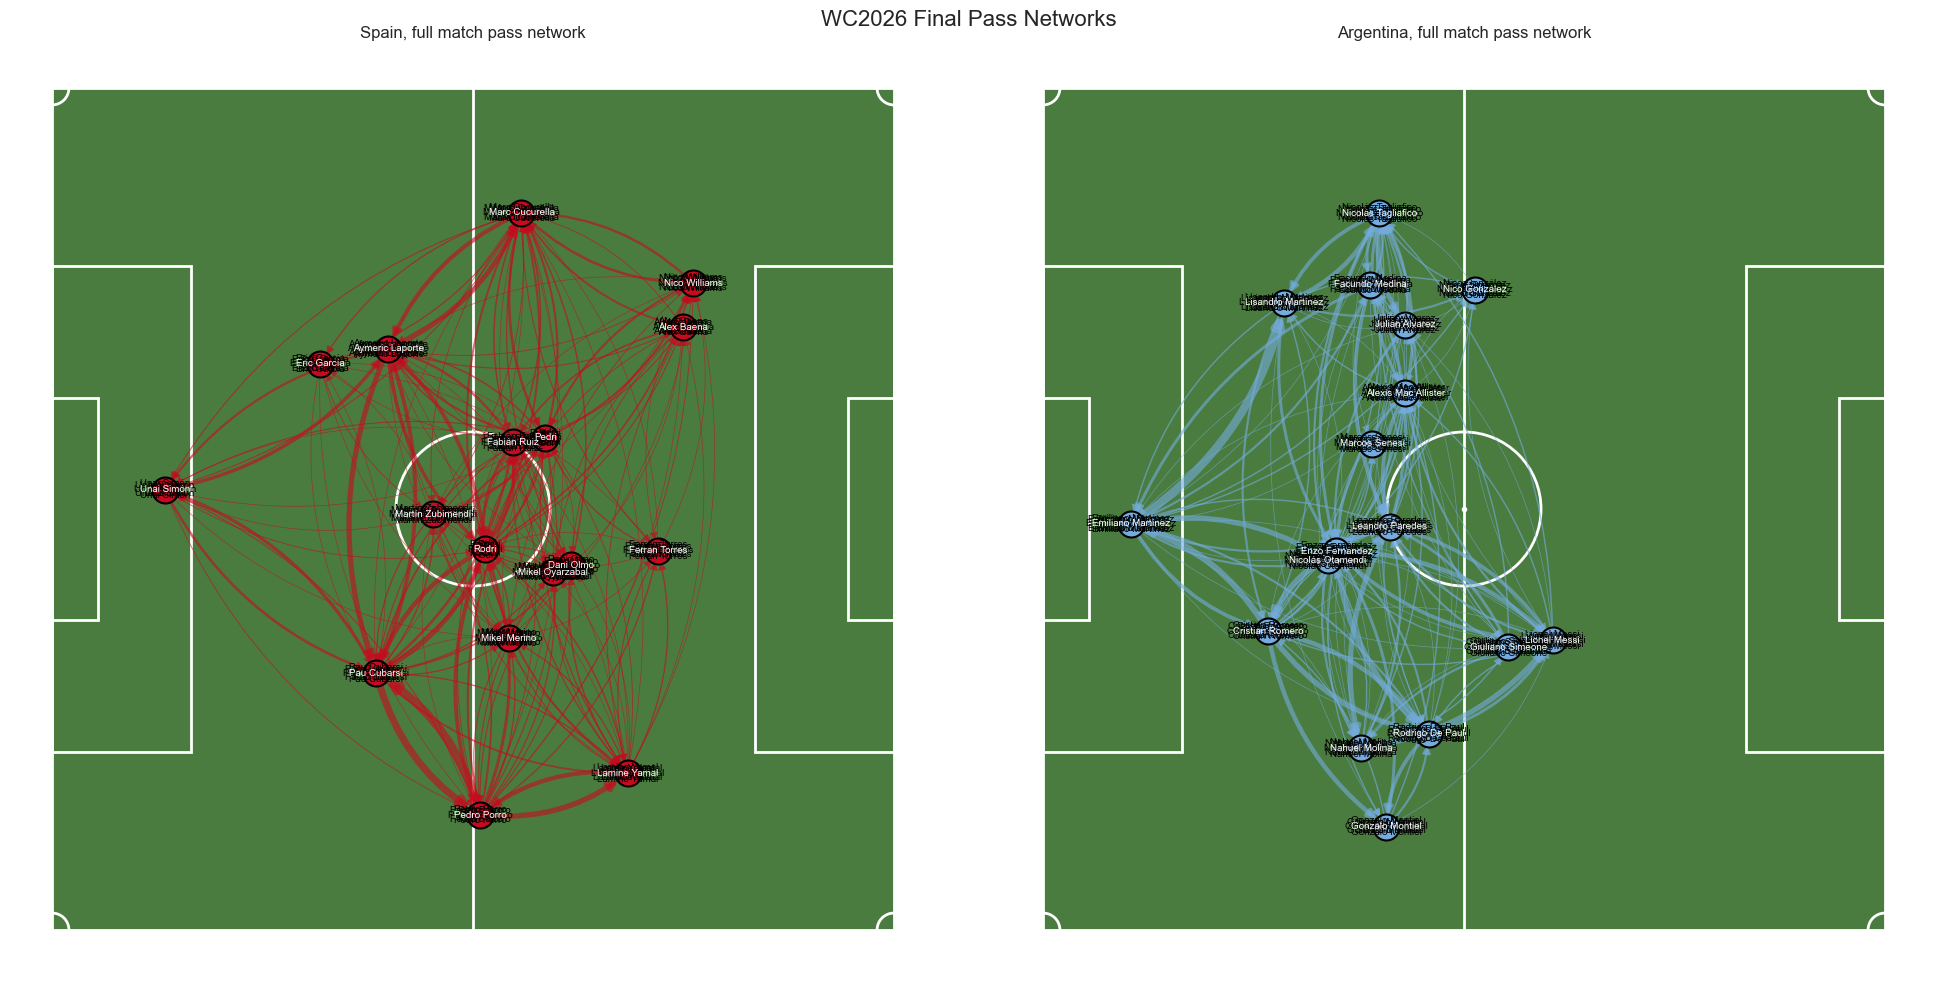

In [7]:
def draw_on_pitch(G, ax, title):
    draw_pitch_background(ax)
    team_color = get_team_color_from_title(title)

    if G.number_of_nodes() == 0:
        ax.set_title(title, fontsize=12)
        ax.text(50, 50, 'No data', color='white', fontsize=12, ha='center', va='center', zorder=6)
        return

    weights = [data['weight'] for _, _, data in G.edges(data=True)]
    if len(weights) > 0:
        min_weight = min(weights)
        max_weight = max(weights)
    else:
        min_weight = max_weight = 1

    for u, v, data in G.edges(data=True):
        x1, y1 = G.nodes[u].get('avg_x'), G.nodes[u].get('avg_y')
        x2, y2 = G.nodes[v].get('avg_x'), G.nodes[v].get('avg_y')
        if x1 is None or y1 is None or x2 is None or y2 is None:
            continue
        width = scale_edge_width(data['weight'], min_weight, max_weight)
        draw_curved_edge(ax, x1, y1, x2, y2, width, team_color)

    for node, data in G.nodes(data=True):
        x, y = data.get('avg_x'), data.get('avg_y')
        if x is None or y is None:
            continue
        ax.scatter([x], [y], s=350, color=team_color, edgecolor='black', linewidth=1.5, zorder=5)
        draw_player_label(ax, x, y, node)

    ax.set_title(title, fontsize=12)


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
draw_on_pitch(G_spain, axes[0], 'Spain, full match pass network')
draw_on_pitch(G_argentina, axes[1], 'Argentina, full match pass network')
fig.suptitle('WC2026 Final Pass Networks', fontsize=16)
fig.tight_layout()

try:
    fig.savefig('../pics/pitch_visualization.png', dpi=150, bbox_inches='tight')
    print('Saved pitch_visualization.png')
except Exception as e:
    print('Failed to save pitch_visualization.png:', e)
    raise

plt.show()

## Section 2, Network Characteristics

In [8]:
def compute_basic_characteristics(G):
    G_undirected = G.to_undirected()
    return {
        'Number of nodes (players)': G.number_of_nodes(),
        'Number of edges (unique connections)': G.number_of_edges(),
        'Total passes (sum of edge weights)': graph_total_weight(G),
        'Density': nx.density(G),
        'Weakly connected components': nx.number_weakly_connected_components(G),
        'Strongly connected components': nx.number_strongly_connected_components(G),
        'Average clustering coefficient (undirected)': nx.average_clustering(G_undirected, weight='weight'),
        'Transitivity (undirected)': nx.transitivity(G_undirected)
    }

basic_characteristics = pd.DataFrame({
    'Spain': compute_basic_characteristics(G_spain),
    'Argentina': compute_basic_characteristics(G_argentina)
})

print('Basic network characteristics, Spain versus Argentina:')
print(basic_characteristics.to_string())

Basic network characteristics, Spain versus Argentina:
                                                  Spain   Argentina
Number of nodes (players)                     17.000000   17.000000
Number of edges (unique connections)         163.000000  147.000000
Total passes (sum of edge weights)           792.000000  377.000000
Density                                        0.599265    0.540441
Weakly connected components                    1.000000    1.000000
Strongly connected components                  1.000000    1.000000
Average clustering coefficient (undirected)    0.074822    0.225504
Transitivity (undirected)                      0.764067    0.730640


Since these are small graphs, 17 nodes each, all exact distance
computations are feasible without sampling. The distance metrics below are
computed on the largest weakly connected component of each graph.

In [9]:
def compute_distance_metrics(G):
    largest_component_nodes = max(nx.weakly_connected_components(G), key=len)
    G_component = G.subgraph(largest_component_nodes).copy()

    eccentricity = nx.eccentricity(G_component)

    metrics = {
        'Component size': G_component.number_of_nodes(),
        'Average shortest path length': nx.average_shortest_path_length(G_component, weight=None),
        'Diameter': nx.diameter(G_component),
        'Radius': nx.radius(G_component),
        'Periphery': ', '.join(sorted(nx.periphery(G_component))),
        'Center': ', '.join(sorted(nx.center(G_component)))
    }
    return metrics, eccentricity

spain_distance_metrics, spain_eccentricity = compute_distance_metrics(G_spain)
argentina_distance_metrics, argentina_eccentricity = compute_distance_metrics(G_argentina)

distance_comparison = pd.DataFrame({
    'Spain': spain_distance_metrics,
    'Argentina': argentina_distance_metrics
})

print('Distance metrics computed on the largest weakly connected component of each graph:')
print(distance_comparison.to_string())

Distance metrics computed on the largest weakly connected component of each graph:
                                                                                                                                                                                                                                         Spain                                                                                                                                                                      Argentina
Component size                                                                                                                                                                                                                              17                                                                                                                                                                             17
Average shortest path length                                                             

In [10]:
spain_eccentricity_df = pd.DataFrame(list(spain_eccentricity.items()), columns=['Player', 'Eccentricity']).sort_values('Eccentricity').reset_index(drop=True)
argentina_eccentricity_df = pd.DataFrame(list(argentina_eccentricity.items()), columns=['Player', 'Eccentricity']).sort_values('Eccentricity').reset_index(drop=True)

print('Spain player eccentricity, sorted ascending:')
print(spain_eccentricity_df.to_string(index=False))
print()
print('Argentina player eccentricity, sorted ascending:')
print(argentina_eccentricity_df.to_string(index=False))

Spain player eccentricity, sorted ascending:
          Player  Eccentricity
 Aymeric Laporte             2
Martín Zubimendi             2
     Pedro Porro             2
    Mikel Merino             2
   Nico Williams             2
           Pedri             2
     Eric García             2
    Lamine Yamal             2
           Rodri             2
  Marc Cucurella             2
      Álex Baena             2
       Dani Olmo             2
     Fabián Ruiz             2
     Pau Cubarsí             2
      Unai Simón             2
   Ferran Torres             2
 Mikel Oyarzabal             3

Argentina player eccentricity, sorted ascending:
             Player  Eccentricity
       Lionel Messi             2
 Nicolás Tagliafico             2
      Nahuel Molina             2
   Giuliano Simeone             2
  Emiliano Martínez             2
Alexis Mac Allister             2
   Nicolás Otamendi             2
    Cristian Romero             2
     Enzo Fernández             2
    Lea

[INTERPRETATION: what do these numbers reveal about each team's passing
structure. Is one team more densely connected. Does the average path
length suggest a more distributed or centralized style.]

## Section 3, Centrality Measures

For a directed weighted pass network, multiple centrality measures reveal
different aspects of a player role. In degree centrality shows who
receives the most passes, identifying target players and focal points.
Out degree centrality shows who distributes the most passes, identifying
playmakers. Betweenness centrality shows who acts as a bridge or pivot in
the passing network. Eigenvector centrality shows who passes to other
highly connected players. PageRank shows who receives passes from
important players, and its weighted version captures pass quality rather
than only pass quantity.

In [11]:
def compute_centralities(G):
    in_degree = nx.in_degree_centrality(G)
    out_degree = nx.out_degree_centrality(G)
    betweenness = nx.betweenness_centrality(G, normalized=True)
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
    pagerank = nx.pagerank(G, weight='weight')
    return {
        'in_degree': in_degree,
        'out_degree': out_degree,
        'betweenness': betweenness,
        'eigenvector': eigenvector,
        'pagerank': pagerank
    }

spain_centralities = compute_centralities(G_spain)
argentina_centralities = compute_centralities(G_argentina)

print('Centrality measures computed for Spain and Argentina, covering in degree, out degree, betweenness, eigenvector, and pagerank.')

Centrality measures computed for Spain and Argentina, covering in degree, out degree, betweenness, eigenvector, and pagerank.


Saved ../pics/centrality_in_degree.png


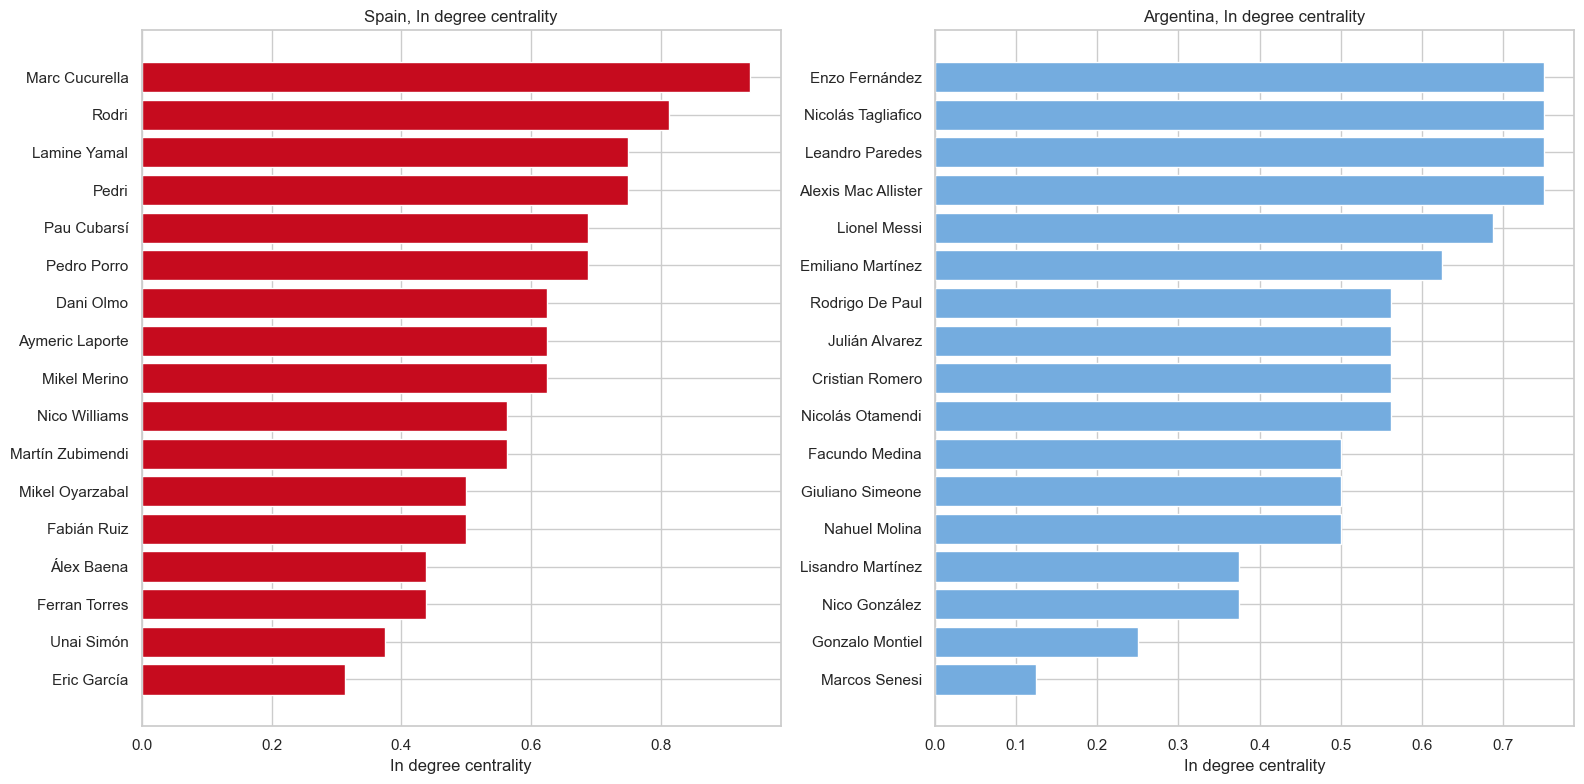

Saved ../pics/centrality_out_degree.png


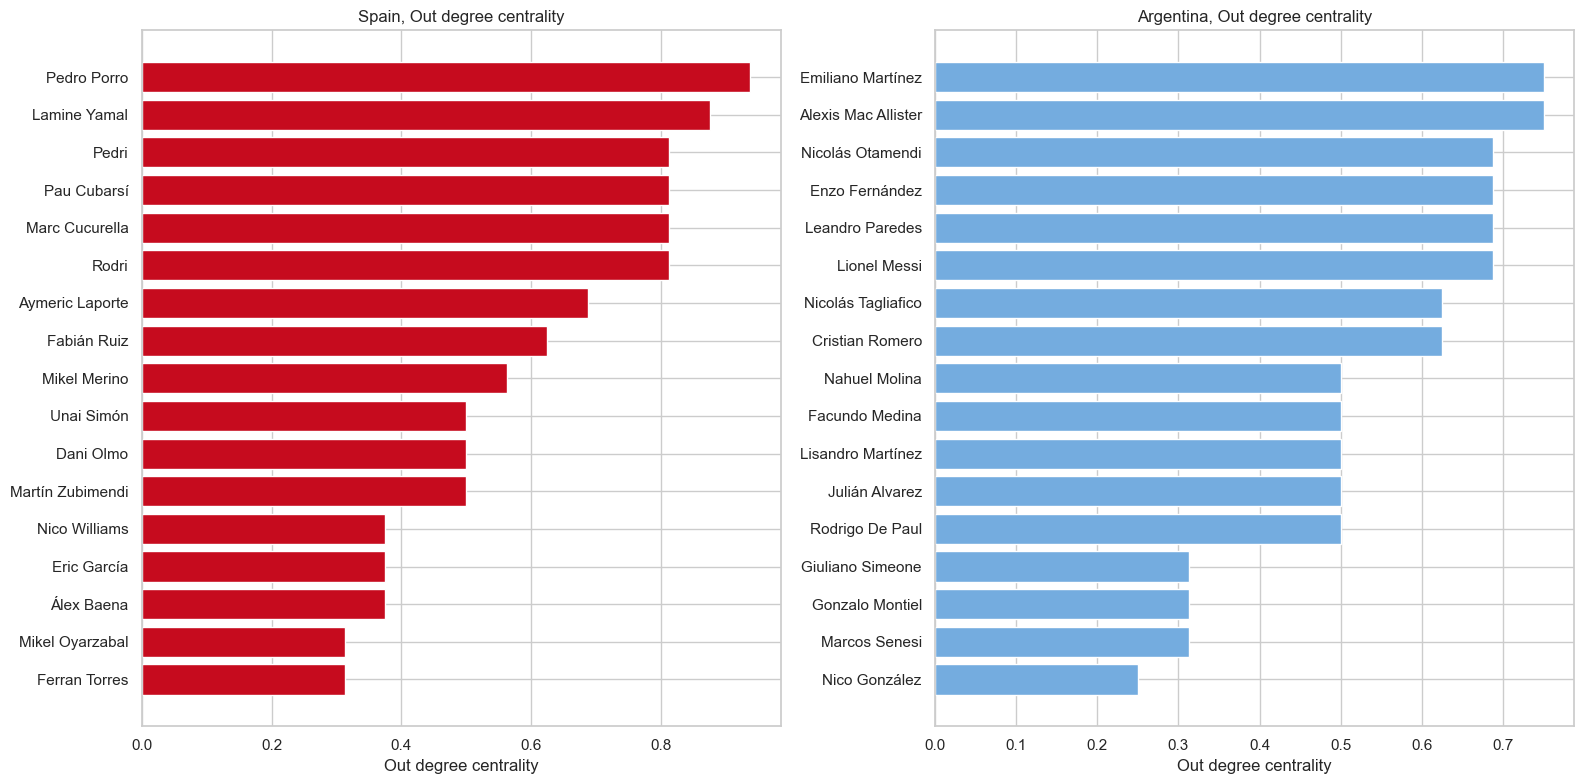

Saved ../pics/centrality_betweenness.png


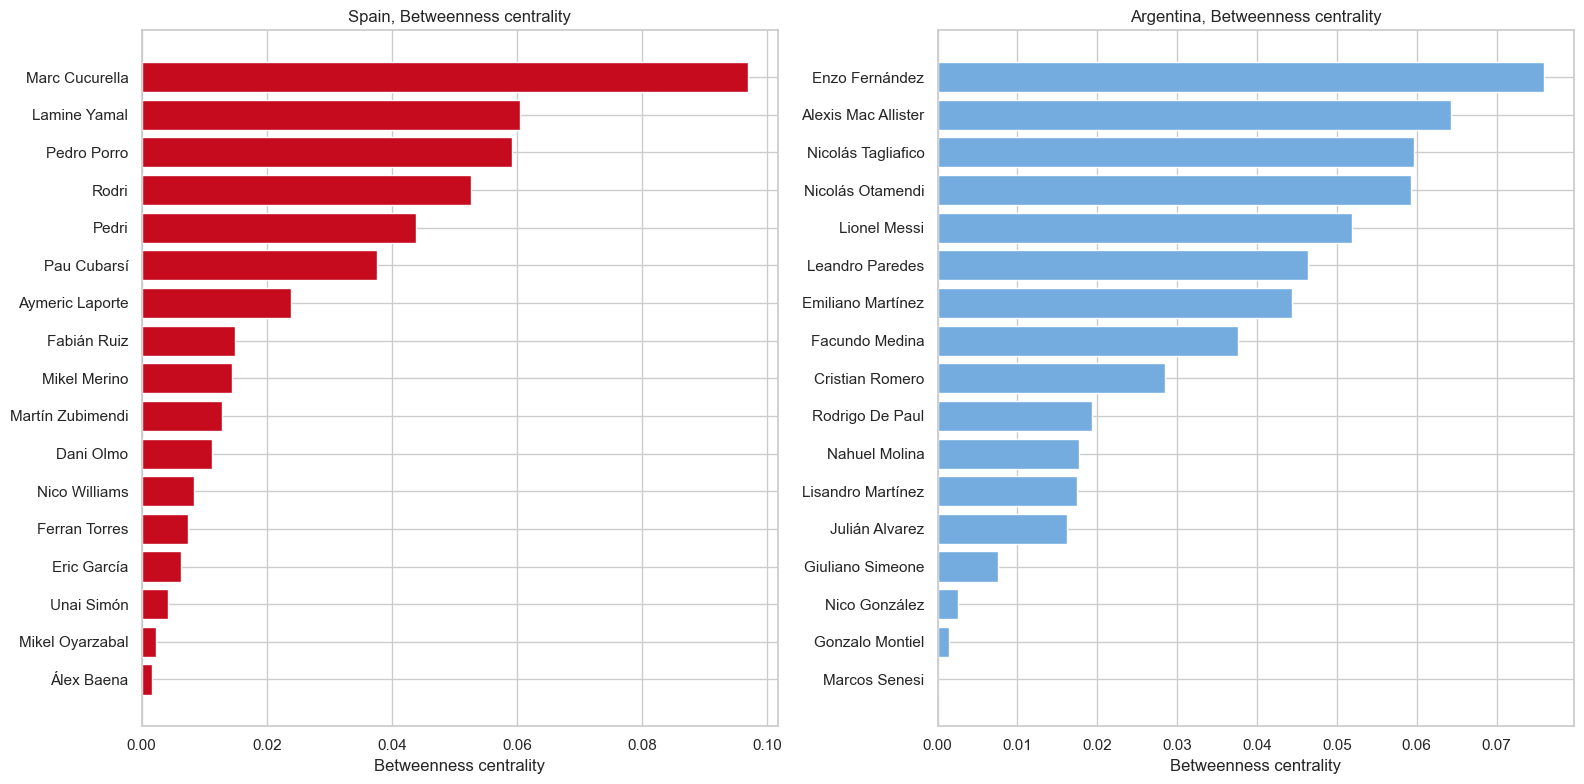

Saved ../pics/centrality_eigenvector.png


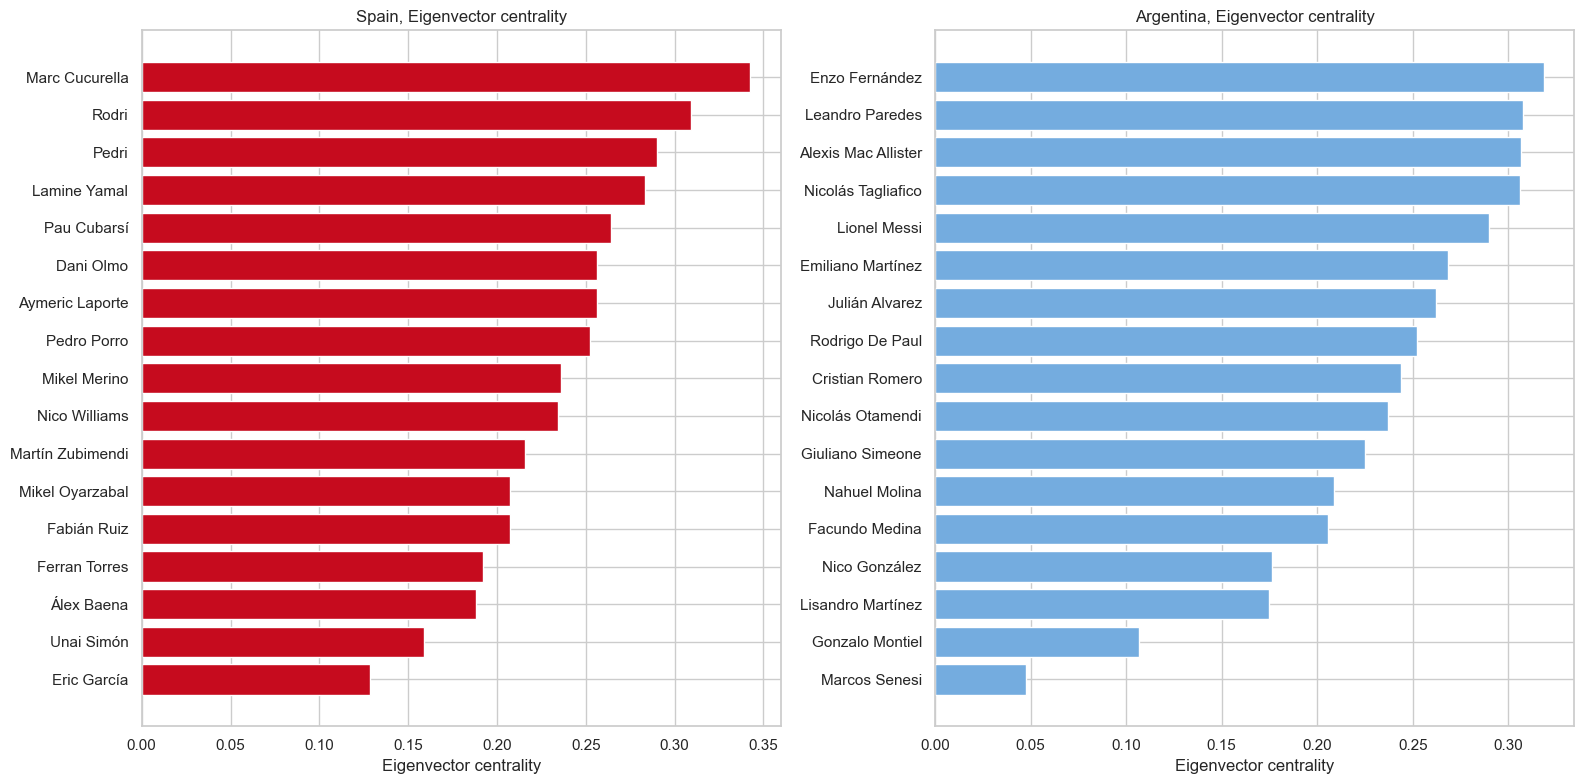

Saved ../pics/centrality_pagerank.png


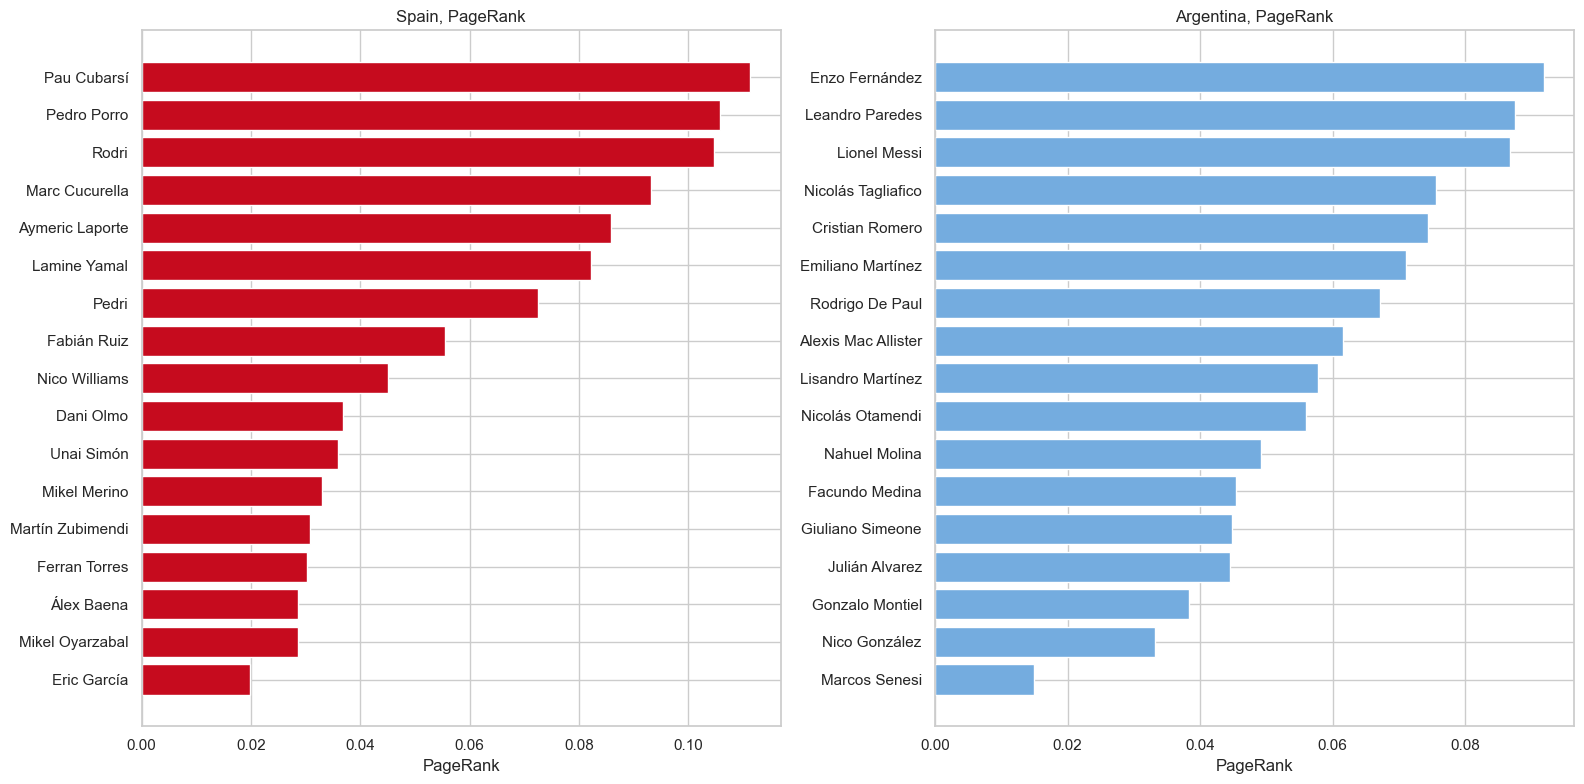

In [12]:
def plot_centrality_comparison(measure_key, measure_label):
    spain_series = pd.Series(spain_centralities[measure_key]).sort_values(ascending=True)
    argentina_series = pd.Series(argentina_centralities[measure_key]).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].barh(spain_series.index, spain_series.values, color=SPAIN_COLOR)
    axes[0].set_title('Spain, ' + measure_label, fontsize=12)
    axes[0].set_xlabel(measure_label)

    axes[1].barh(argentina_series.index, argentina_series.values, color=ARGENTINA_COLOR)
    axes[1].set_title('Argentina, ' + measure_label, fontsize=12)
    axes[1].set_xlabel(measure_label)

    fig.tight_layout()

    filename = '../pics/centrality_' + measure_key + '.png'
    try:
        fig.savefig(filename, dpi=150, bbox_inches='tight')
        print('Saved', filename)
    except Exception as e:
        print('Failed to save', filename, ':', e)
        raise

    plt.show()

measure_labels = {
    'in_degree': 'In degree centrality',
    'out_degree': 'Out degree centrality',
    'betweenness': 'Betweenness centrality',
    'eigenvector': 'Eigenvector centrality',
    'pagerank': 'PageRank'
}

for measure_key, measure_label in measure_labels.items():
    plot_centrality_comparison(measure_key, measure_label)

In [13]:
def build_centrality_summary(centralities):
    df = pd.DataFrame({
        'In degree': centralities['in_degree'],
        'Out degree': centralities['out_degree'],
        'Betweenness': centralities['betweenness'],
        'Eigenvector': centralities['eigenvector'],
        'PageRank': centralities['pagerank']
    })
    return df.sort_values('PageRank', ascending=False)

spain_centrality_summary = build_centrality_summary(spain_centralities)
argentina_centrality_summary = build_centrality_summary(argentina_centralities)

print('Spain, all centrality measures per player, sorted by PageRank descending:')
print(spain_centrality_summary.to_string())
print()
print('Argentina, all centrality measures per player, sorted by PageRank descending:')
print(argentina_centrality_summary.to_string())

Spain, all centrality measures per player, sorted by PageRank descending:
                  In degree  Out degree  Betweenness  Eigenvector  PageRank
Pau Cubarsí          0.6875      0.8125     0.037594     0.264372  0.111315
Pedro Porro          0.6875      0.9375     0.059243     0.252264  0.105710
Rodri                0.8125      0.8125     0.052669     0.309206  0.104757
Marc Cucurella       0.9375      0.8125     0.096921     0.342570  0.093223
Aymeric Laporte      0.6250      0.6875     0.023943     0.256314  0.085940
Lamine Yamal         0.7500      0.8750     0.060527     0.283573  0.082234
Pedri                0.7500      0.8125     0.043914     0.289821  0.072549
Fabián Ruiz          0.5000      0.6250     0.014859     0.207465  0.055451
Nico Williams        0.5625      0.3750     0.008348     0.234485  0.044971
Dani Olmo            0.6250      0.5000     0.011214     0.256502  0.036906
Unai Simón           0.3750      0.5000     0.004148     0.159037  0.035966
Mikel Merino  

In degree identifies the players who are most sought out as receivers,
useful for finding the team offensive focal point.

Betweenness identifies players who connect different parts of the team,
and their removal would fragment the passing network.

PageRank is most appropriate for weighted directed pass networks because
it accounts for both the quantity and quality of passes received.

## Section 4, Degree Distribution

In [14]:
spain_in_degree_weighted = dict(G_spain.in_degree(weight='weight'))
spain_out_degree_weighted = dict(G_spain.out_degree(weight='weight'))
argentina_in_degree_weighted = dict(G_argentina.in_degree(weight='weight'))
argentina_out_degree_weighted = dict(G_argentina.out_degree(weight='weight'))

spain_in_degree_unweighted = dict(G_spain.in_degree())
spain_out_degree_unweighted = dict(G_spain.out_degree())
argentina_in_degree_unweighted = dict(G_argentina.in_degree())
argentina_out_degree_unweighted = dict(G_argentina.out_degree())

print('Weighted and unweighted in degree and out degree sequences computed for both teams.')

Weighted and unweighted in degree and out degree sequences computed for both teams.


Saved degree_distribution.png


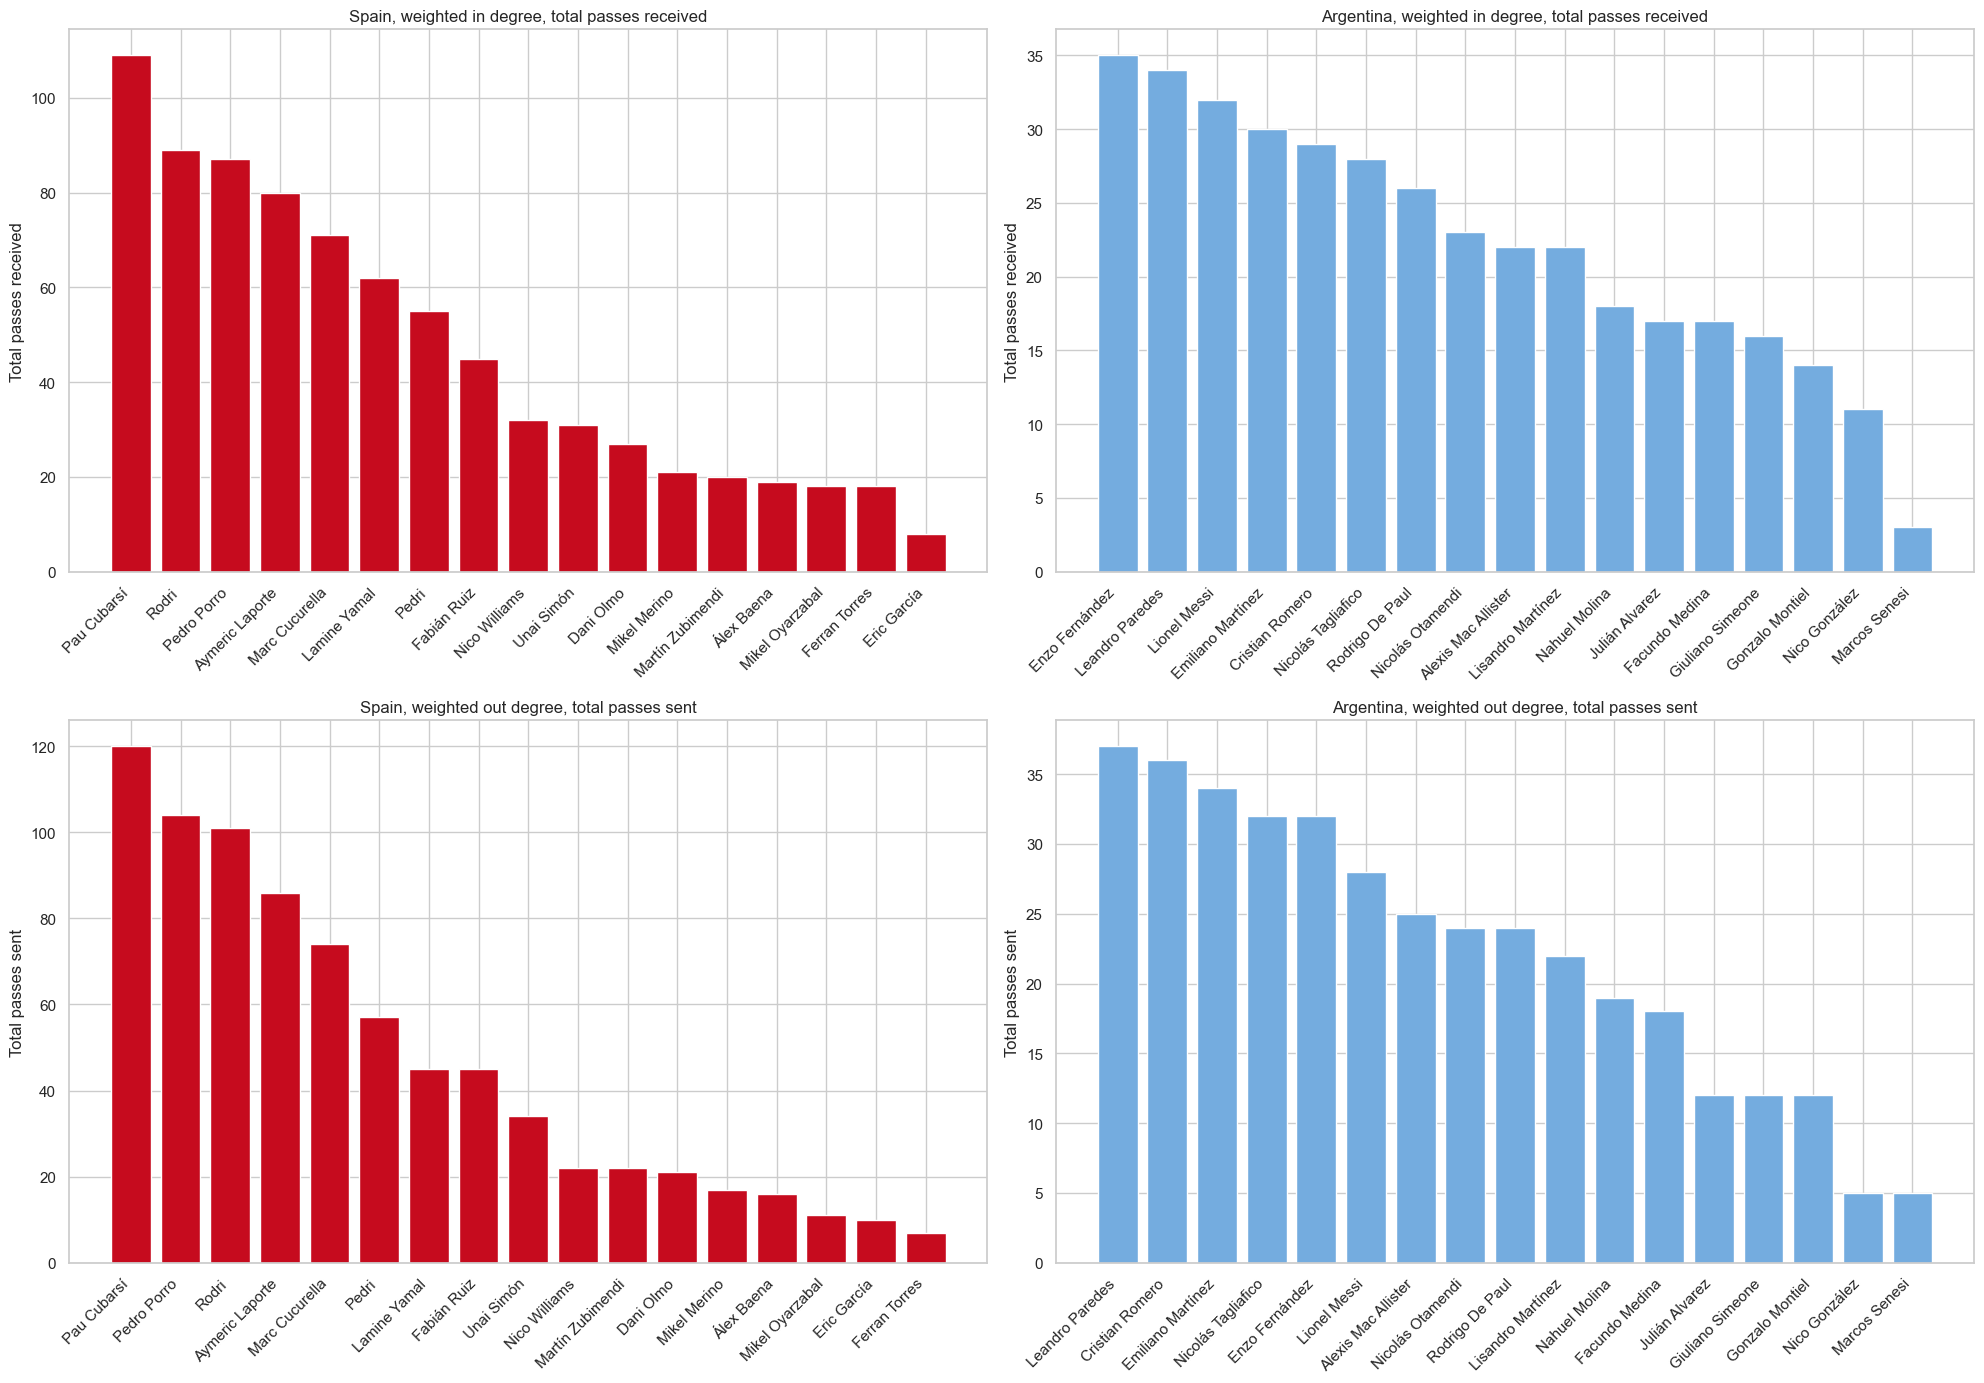

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

spain_in_sorted = pd.Series(spain_in_degree_weighted).sort_values(ascending=False)
argentina_in_sorted = pd.Series(argentina_in_degree_weighted).sort_values(ascending=False)
spain_out_sorted = pd.Series(spain_out_degree_weighted).sort_values(ascending=False)
argentina_out_sorted = pd.Series(argentina_out_degree_weighted).sort_values(ascending=False)

axes[0, 0].bar(spain_in_sorted.index, spain_in_sorted.values, color=SPAIN_COLOR)
axes[0, 0].set_title('Spain, weighted in degree, total passes received', fontsize=12)
axes[0, 0].set_ylabel('Total passes received')
axes[0, 0].tick_params(axis='x', rotation=45)
for label in axes[0, 0].get_xticklabels():
    label.set_ha('right')

axes[0, 1].bar(argentina_in_sorted.index, argentina_in_sorted.values, color=ARGENTINA_COLOR)
axes[0, 1].set_title('Argentina, weighted in degree, total passes received', fontsize=12)
axes[0, 1].set_ylabel('Total passes received')
axes[0, 1].tick_params(axis='x', rotation=45)
for label in axes[0, 1].get_xticklabels():
    label.set_ha('right')

axes[1, 0].bar(spain_out_sorted.index, spain_out_sorted.values, color=SPAIN_COLOR)
axes[1, 0].set_title('Spain, weighted out degree, total passes sent', fontsize=12)
axes[1, 0].set_ylabel('Total passes sent')
axes[1, 0].tick_params(axis='x', rotation=45)
for label in axes[1, 0].get_xticklabels():
    label.set_ha('right')

axes[1, 1].bar(argentina_out_sorted.index, argentina_out_sorted.values, color=ARGENTINA_COLOR)
axes[1, 1].set_title('Argentina, weighted out degree, total passes sent', fontsize=12)
axes[1, 1].set_ylabel('Total passes sent')
axes[1, 1].tick_params(axis='x', rotation=45)
for label in axes[1, 1].get_xticklabels():
    label.set_ha('right')

fig.tight_layout()

try:
    fig.savefig('../pics/degree_distribution.png', dpi=150, bbox_inches='tight')
    print('Saved degree_distribution.png')
except Exception as e:
    print('Failed to save degree_distribution.png:', e)
    raise

plt.show()

Pass networks of 17 nodes do not follow a power law or scale free
distribution. Unlike social media networks where degree follows a heavy
tail, pass networks are constrained by tactical formations, every player
must both send and receive passes within a bounded system of 11 players.
The distribution is expected to be more uniform than a typical social
network, and any skew reveals tactical concentration around specific
players.


## Section 5, Temporal Analysis

The match is divided into four phases. Phase 1 is the first half. Phase 2
is the second half before Enzo Fernandez received the red card at
expandedMinute 97. Phase 3 is the second half after the red card, and
G_arg_p3 is empty for the reason noted in Section 0. Phase 4 is extra
time, where Argentina played with 10 men for the entire duration.

In [16]:
phase_graphs = {
    'Phase 1, first half': {'Spain': G_spain_p1, 'Argentina': G_arg_p1},
    'Phase 2, before red card': {'Spain': G_spain_p2, 'Argentina': G_arg_p2},
    'Phase 3, after red card': {'Spain': G_spain_p3, 'Argentina': G_arg_p3},
    'Phase 4, extra time': {'Spain': G_spain_p4, 'Argentina': G_arg_p4}
}

phase_records = []
for phase_name, team_graphs in phase_graphs.items():
    for team_name, G_phase in team_graphs.items():
        phase_records.append({
            'Phase': phase_name,
            'Team': team_name,
            'Active players (nodes)': G_phase.number_of_nodes(),
            'Unique connections (edges)': G_phase.number_of_edges(),
            'Total passes (sum of weights)': graph_total_weight(G_phase),
            'Density': nx.density(G_phase)
        })

phase_comparison = pd.DataFrame(phase_records).set_index(['Phase', 'Team'])

print('Temporal phase comparison, Spain and Argentina across all four phases:')
print(phase_comparison.to_string())

Temporal phase comparison, Spain and Argentina across all four phases:
                                    Active players (nodes)  Unique connections (edges)  Total passes (sum of weights)   Density
Phase                    Team                                                                                                  
Phase 1, first half      Spain                          11                          79                            327  0.718182
                         Argentina                      12                          66                            164  0.500000
Phase 2, before red card Spain                          15                          94                            263  0.447619
                         Argentina                      14                          75                            118  0.412088
Phase 3, after red card  Spain                           9                          13                             14  0.180556
                         Argentin

Saved temporal_networks.png


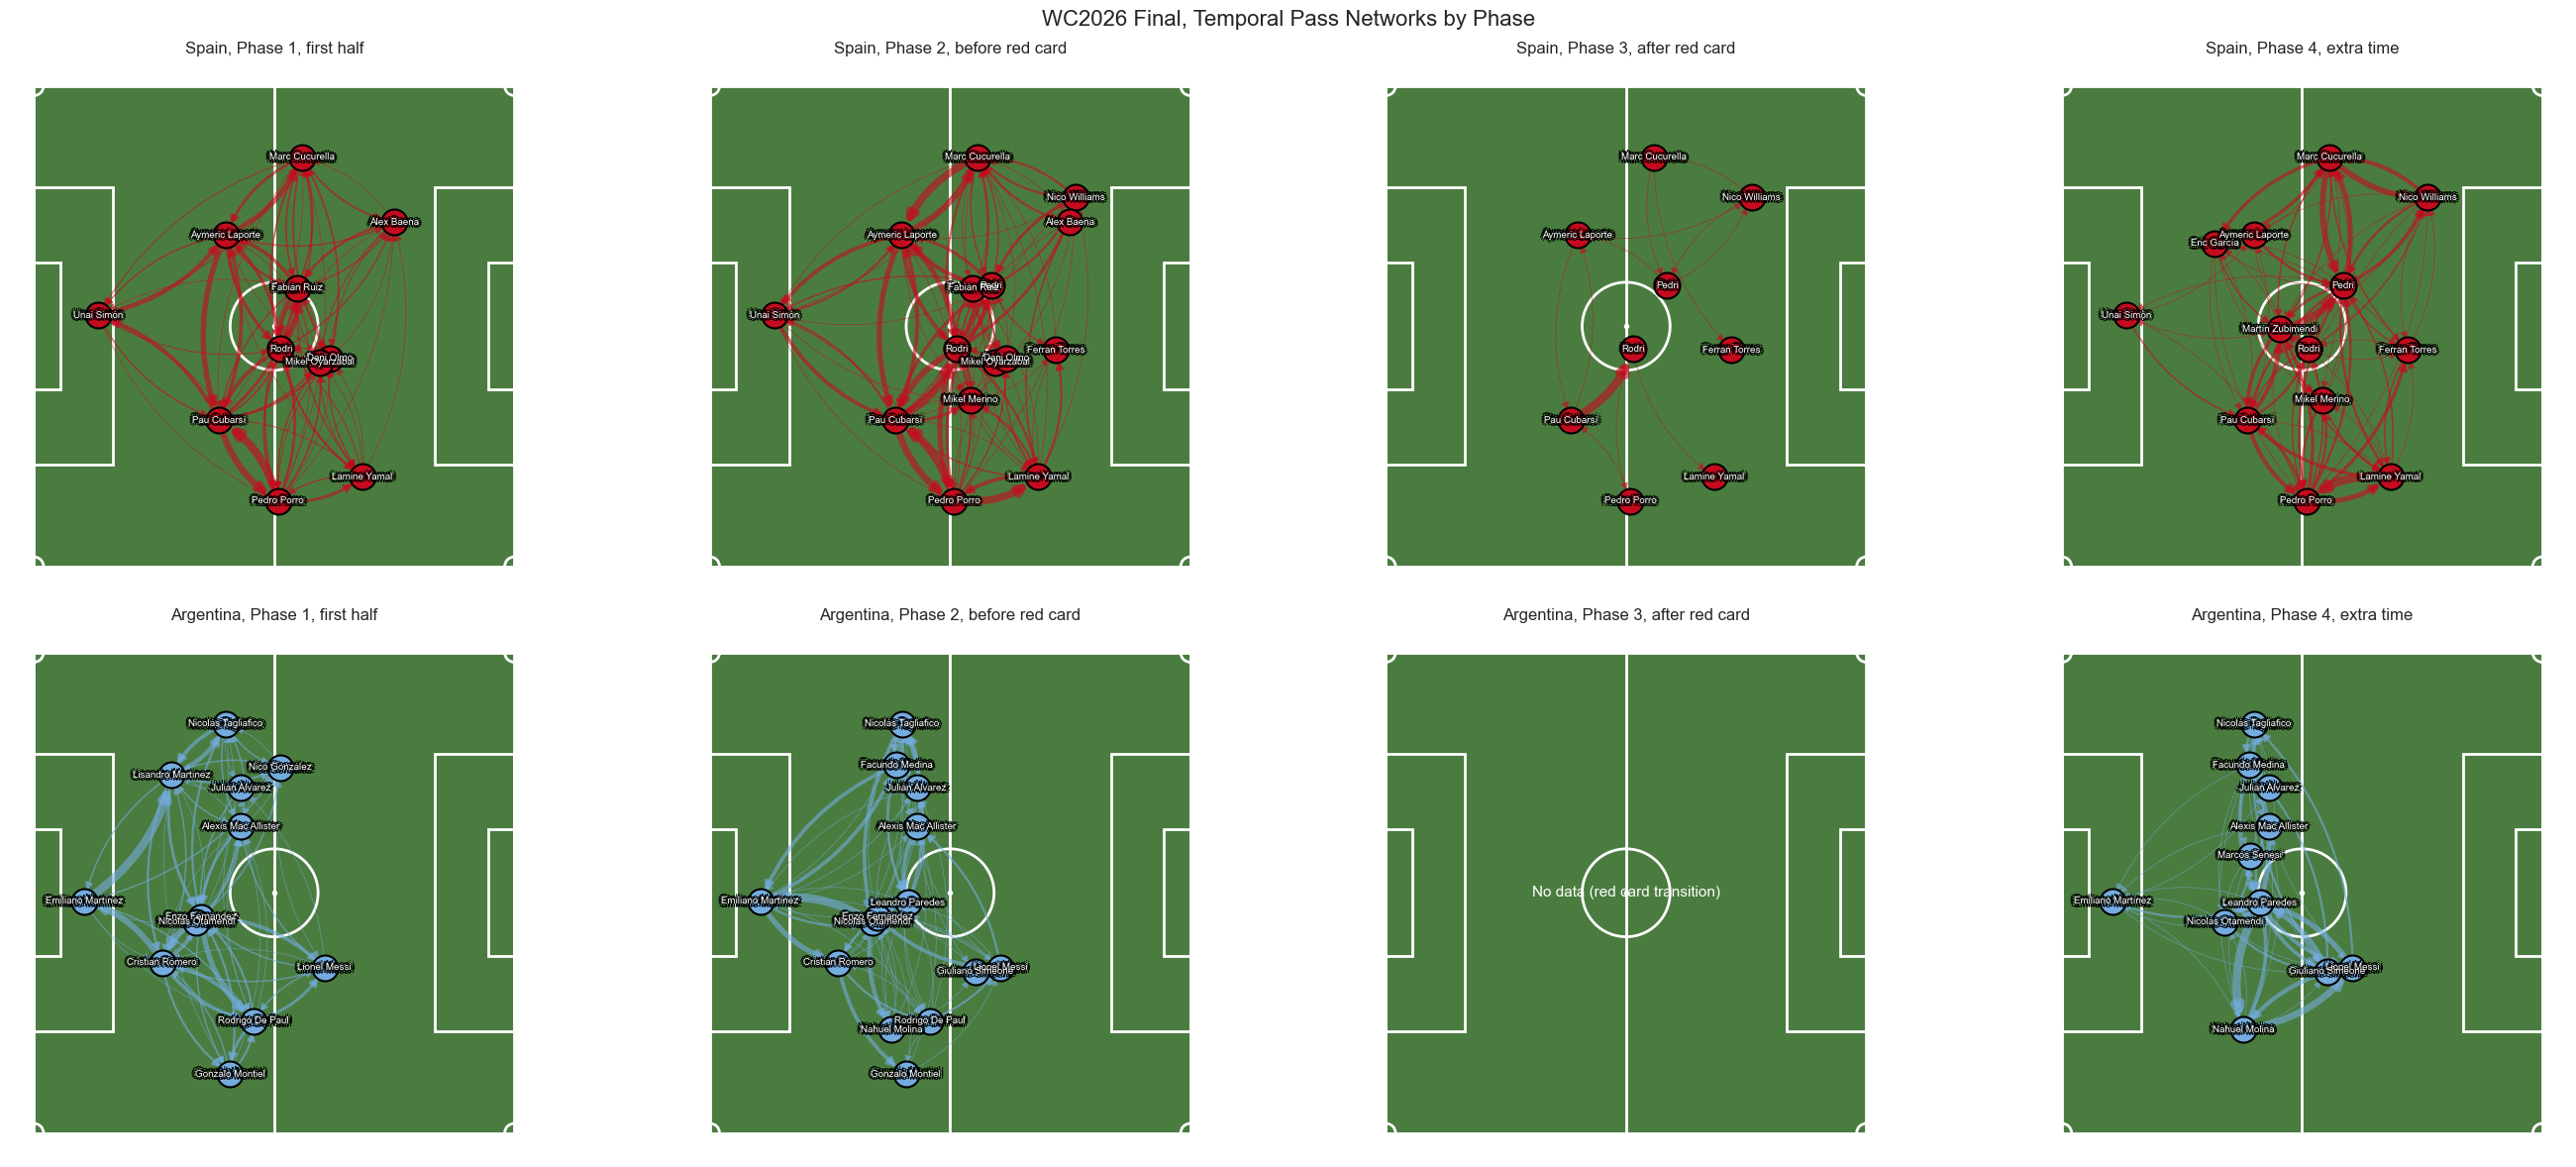

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

phase_order = ['Phase 1, first half', 'Phase 2, before red card', 'Phase 3, after red card', 'Phase 4, extra time']

for col, phase_name in enumerate(phase_order):
    G_spain_phase = phase_graphs[phase_name]['Spain']
    draw_on_pitch(G_spain_phase, axes[0, col], 'Spain, ' + phase_name)

    G_argentina_phase = phase_graphs[phase_name]['Argentina']
    if G_argentina_phase.number_of_nodes() == 0:
        draw_pitch_background(axes[1, col])
        axes[1, col].set_title('Argentina, ' + phase_name, fontsize=12)
        axes[1, col].text(50, 50, 'No data (red card transition)', color='white', fontsize=11, ha='center', va='center', zorder=6)
    else:
        draw_on_pitch(G_argentina_phase, axes[1, col], 'Argentina, ' + phase_name)

fig.suptitle('WC2026 Final, Temporal Pass Networks by Phase', fontsize=16)
fig.tight_layout()

try:
    fig.savefig('../pics/temporal_networks.png', dpi=150, bbox_inches='tight')
    print('Saved temporal_networks.png')
except Exception as e:
    print('Failed to save temporal_networks.png:', e)
    raise

plt.show()

## Section 6, Community Detection and Triangle Analysis

Two complementary approaches are used to analyze passing combinations.
First, standard community detection finds groups of players who passed
among themselves more than to the rest of the team. Second, directed
triangle detection finds explicit passing triangles, A to B to C back to
A, which are a known tactical pattern in possession football.

### Part A, community detection with Louvain

Note that to_undirected() keeps the attributes of only one of the two
directed edges when both directions exist between a pair of players, it
does not sum them, so the undirected weight used below is a simplification
of the true bidirectional passing volume between two players.

In [18]:
G_spain_undirected = G_spain.to_undirected()
G_argentina_undirected = G_argentina.to_undirected()

spain_partition = community_louvain.best_partition(G_spain_undirected, weight='weight', random_state=42)
argentina_partition = community_louvain.best_partition(G_argentina_undirected, weight='weight', random_state=42)

spain_modularity = community_louvain.modularity(spain_partition, G_spain_undirected, weight='weight')
argentina_modularity = community_louvain.modularity(argentina_partition, G_argentina_undirected, weight='weight')

print('Spain, number of communities found:', len(set(spain_partition.values())), ', modularity score:', spain_modularity)
print('Argentina, number of communities found:', len(set(argentina_partition.values())), ', modularity score:', argentina_modularity)

Spain, number of communities found: 3 , modularity score: 0.16159013605442174
Argentina, number of communities found: 3 , modularity score: 0.18335800431944482


Saved communities_louvain.png


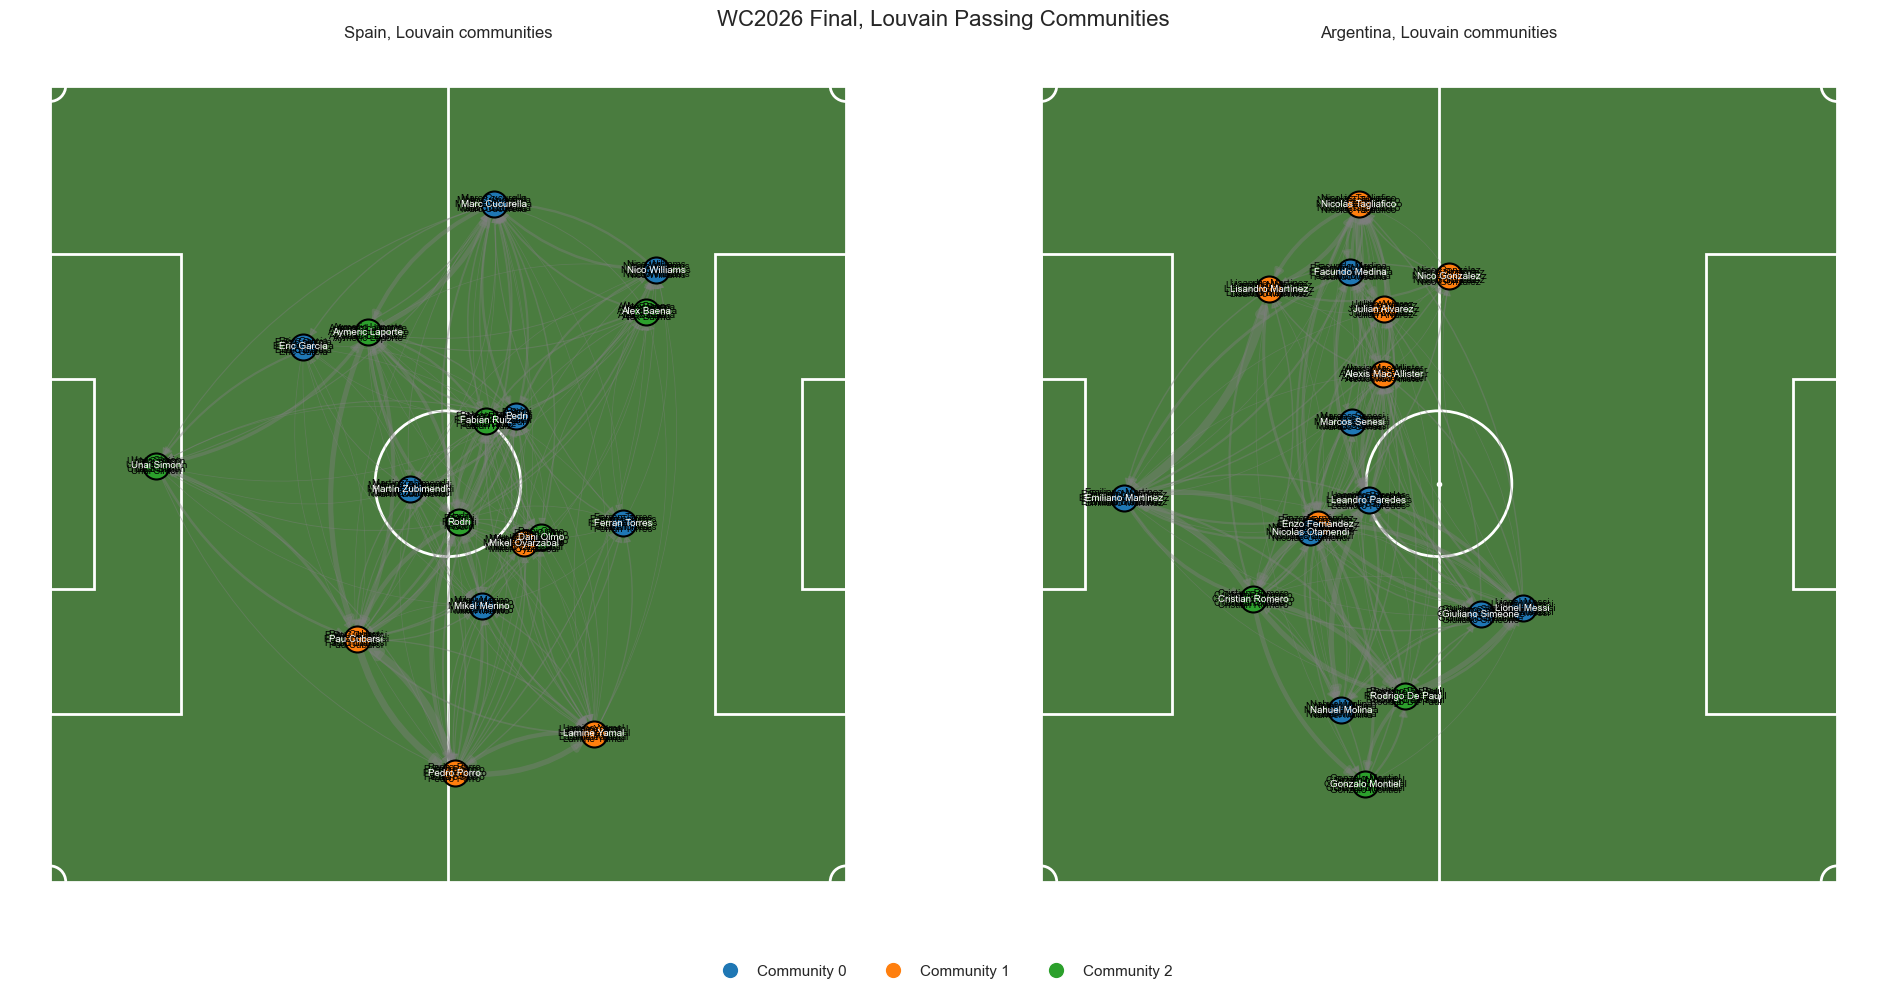

In [19]:
def draw_communities_on_pitch(G, partition, ax, title):
    draw_pitch_background(ax)
    cmap = plt.get_cmap('tab10')

    weights = [data['weight'] for _, _, data in G.edges(data=True)]
    min_weight = min(weights) if len(weights) > 0 else 1
    max_weight = max(weights) if len(weights) > 0 else 1

    for u, v, data in G.edges(data=True):
        x1, y1 = G.nodes[u].get('avg_x'), G.nodes[u].get('avg_y')
        x2, y2 = G.nodes[v].get('avg_x'), G.nodes[v].get('avg_y')
        if x1 is None or y1 is None or x2 is None or y2 is None:
            continue
        width = scale_edge_width(data['weight'], min_weight, max_weight)
        draw_curved_edge(ax, x1, y1, x2, y2, width, 'grey', alpha=0.4)

    for node, data in G.nodes(data=True):
        x, y = data.get('avg_x'), data.get('avg_y')
        if x is None or y is None:
            continue
        community_id = partition[node]
        node_color = cmap(community_id % 10)
        ax.scatter([x], [y], s=350, color=node_color, edgecolor='black', linewidth=1.5, zorder=5)
        draw_player_label(ax, x, y, node)

    ax.set_title(title, fontsize=12)


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
draw_communities_on_pitch(G_spain, spain_partition, axes[0], 'Spain, Louvain communities')
draw_communities_on_pitch(G_argentina, argentina_partition, axes[1], 'Argentina, Louvain communities')

cmap = plt.get_cmap('tab10')
all_community_ids = sorted(set(spain_partition.values()) | set(argentina_partition.values()))
legend_handles = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(cid % 10), markersize=12, label='Community ' + str(cid))
    for cid in all_community_ids
]
fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles), frameon=False)

fig.suptitle('WC2026 Final, Louvain Passing Communities', fontsize=16)
fig.tight_layout(rect=[0, 0.05, 1, 1])

try:
    fig.savefig('../pics/communities_louvain.png', dpi=150, bbox_inches='tight')
    print('Saved communities_louvain.png')
except Exception as e:
    print('Failed to save communities_louvain.png:', e)
    raise

plt.show()

In [20]:
def summarize_communities(G, partition, team_name):
    records = []
    community_ids = sorted(set(partition.values()))
    for community_id in community_ids:
        players = [node for node, cid in partition.items() if cid == community_id]
        avg_x_values = [G.nodes[p]['avg_x'] for p in players if G.nodes[p].get('avg_x') is not None]
        avg_y_values = [G.nodes[p]['avg_y'] for p in players if G.nodes[p].get('avg_y') is not None]
        records.append({
            'Team': team_name,
            'Community': community_id,
            'Players': ', '.join(sorted(players)),
            'Number of players': len(players),
            'Average x': np.mean(avg_x_values) if len(avg_x_values) > 0 else None,
            'Average y': np.mean(avg_y_values) if len(avg_y_values) > 0 else None
        })
    return pd.DataFrame(records)

spain_community_summary = summarize_communities(G_spain, spain_partition, 'Spain')
argentina_community_summary = summarize_communities(G_argentina, argentina_partition, 'Argentina')

community_summary = pd.concat([spain_community_summary, argentina_community_summary], ignore_index=True)

print('Community composition and average pitch position, both teams:')
print(community_summary.to_string(index=False))

Community composition and average pitch position, both teams:
     Team  Community                                                                                                                            Players  Number of players  Average x  Average y
    Spain          0                                   Eric García, Ferran Torres, Marc Cucurella, Martín Zubimendi, Mikel Merino, Nico Williams, Pedri                  7  56.253076  59.532323
    Spain          1                                                                            Lamine Yamal, Mikel Oyarzabal, Pau Cubarsí, Pedro Porro                  4  54.310258  26.312702
    Spain          2                                                             Aymeric Laporte, Dani Olmo, Fabián Ruiz, Rodri, Unai Simón, Álex Baena                  6  49.329426  56.559205
Argentina          0 Emiliano Martínez, Facundo Medina, Giuliano Simeone, Leandro Paredes, Lionel Messi, Marcos Senesi, Nahuel Molina, Nicolás Otamendi               

### Part B, directed triangle detection

In [21]:
def find_directed_triangles(G):
    seen_canonical_forms = set()
    triangles = []
    for player_a, player_b, player_c in itertools.permutations(G.nodes(), 3):
        if G.has_edge(player_a, player_b) and G.has_edge(player_b, player_c) and G.has_edge(player_c, player_a):
            rotations = [(player_a, player_b, player_c), (player_b, player_c, player_a), (player_c, player_a, player_b)]
            canonical_form = min(rotations)
            if canonical_form in seen_canonical_forms:
                continue
            seen_canonical_forms.add(canonical_form)
            weight_ab = G[canonical_form[0]][canonical_form[1]]['weight']
            weight_bc = G[canonical_form[1]][canonical_form[2]]['weight']
            weight_ca = G[canonical_form[2]][canonical_form[0]]['weight']
            combined_weight = min(weight_ab, weight_bc, weight_ca)
            triangles.append((canonical_form[0], canonical_form[1], canonical_form[2], combined_weight))
    triangles.sort(key=lambda t: t[3], reverse=True)
    return triangles

In [22]:
spain_triangles = find_directed_triangles(G_spain)
argentina_triangles = find_directed_triangles(G_argentina)

spain_triangles_df = pd.DataFrame(spain_triangles[:10], columns=['Player A', 'Player B', 'Player C', 'Bottleneck Weight'])
argentina_triangles_df = pd.DataFrame(argentina_triangles[:10], columns=['Player A', 'Player B', 'Player C', 'Bottleneck Weight'])

print('Spain, total directed passing triangles found:', len(spain_triangles))
print('Top 10 Spain passing triangles by bottleneck weight:')
print(spain_triangles_df.to_string(index=False))
print()
print('Argentina, total directed passing triangles found:', len(argentina_triangles))
print('Top 10 Argentina passing triangles by bottleneck weight:')
print(argentina_triangles_df.to_string(index=False))

Spain, total directed passing triangles found: 341
Top 10 Spain passing triangles by bottleneck weight:
       Player A    Player B       Player C  Bottleneck Weight
    Pau Cubarsí       Rodri    Pedro Porro                 16
Aymeric Laporte Pau Cubarsí          Rodri                 15
Aymeric Laporte       Rodri    Pau Cubarsí                 14
Aymeric Laporte Pau Cubarsí     Unai Simón                 13
    Pau Cubarsí Pedro Porro          Rodri                 12
    Fabián Ruiz       Rodri    Pau Cubarsí                 10
Aymeric Laporte Pau Cubarsí    Fabián Ruiz                  9
Aymeric Laporte       Rodri    Fabián Ruiz                  9
Aymeric Laporte  Unai Simón    Pau Cubarsí                  8
Aymeric Laporte       Pedri Marc Cucurella                  8

Argentina, total directed passing triangles found: 267
Top 10 Argentina passing triangles by bottleneck weight:
           Player A        Player B        Player C  Bottleneck Weight
    Leandro Paredes   Nahuel M

Saved triangles.png


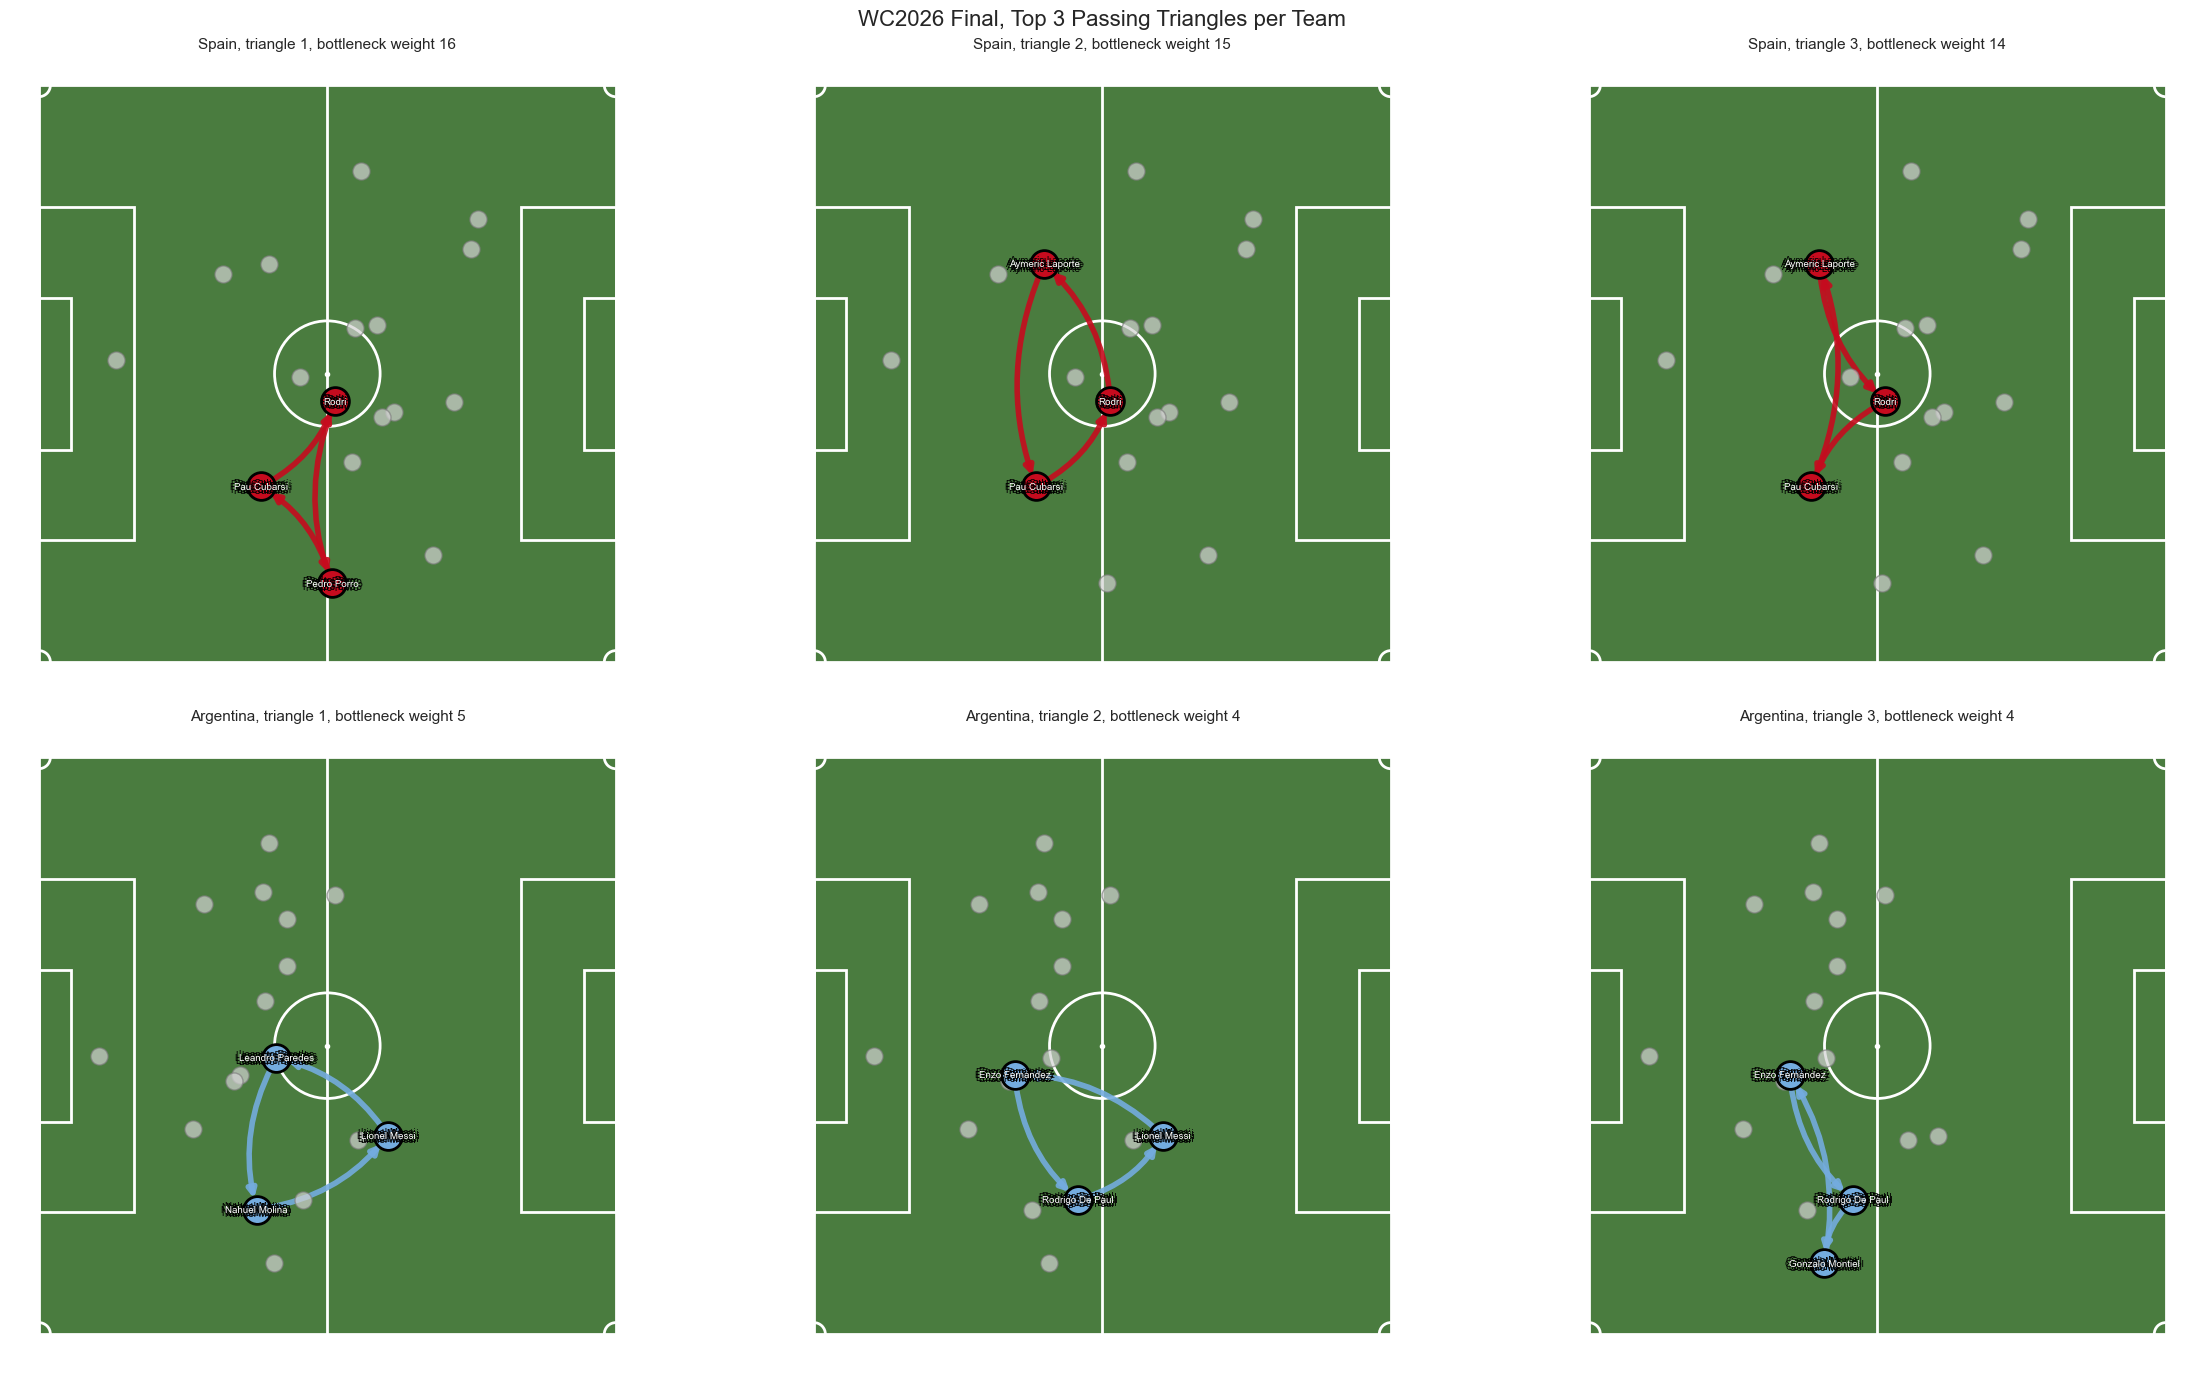

In [23]:
def draw_triangle_on_pitch(G, triangle, ax, title, team_color):
    draw_pitch_background(ax)
    player_a, player_b, player_c, combined_weight = triangle
    highlighted_players = [player_a, player_b, player_c]

    for node, data in G.nodes(data=True):
        if node in highlighted_players:
            continue
        x, y = data.get('avg_x'), data.get('avg_y')
        if x is None or y is None:
            continue
        ax.scatter([x], [y], s=150, color='lightgrey', edgecolor='grey', linewidth=1, zorder=3, alpha=0.7)

    triangle_edges = [(player_a, player_b), (player_b, player_c), (player_c, player_a)]
    for source_player, target_player in triangle_edges:
        x1, y1 = G.nodes[source_player]['avg_x'], G.nodes[source_player]['avg_y']
        x2, y2 = G.nodes[target_player]['avg_x'], G.nodes[target_player]['avg_y']
        draw_curved_edge(ax, x1, y1, x2, y2, 4.0, team_color, alpha=0.9)

    for player in highlighted_players:
        x, y = G.nodes[player]['avg_x'], G.nodes[player]['avg_y']
        ax.scatter([x], [y], s=400, color=team_color, edgecolor='black', linewidth=2, zorder=5)
        draw_player_label(ax, x, y, player)

    ax.set_title(title + ', bottleneck weight ' + str(combined_weight), fontsize=11)


fig, axes = plt.subplots(2, 3, figsize=(24, 14))

for col in range(3):
    draw_triangle_on_pitch(G_spain, spain_triangles[col], axes[0, col], 'Spain, triangle ' + str(col + 1), SPAIN_COLOR)

for col in range(3):
    draw_triangle_on_pitch(G_argentina, argentina_triangles[col], axes[1, col], 'Argentina, triangle ' + str(col + 1), ARGENTINA_COLOR)

fig.suptitle('WC2026 Final, Top 3 Passing Triangles per Team', fontsize=16)
fig.tight_layout()

try:
    fig.savefig('../pics/triangles.png', dpi=150, bbox_inches='tight')
    print('Saved triangles.png')
except Exception as e:
    print('Failed to save triangles.png:', e)
    raise

plt.show()

### Part C, comparison

Louvain communities show which players formed stable passing subgroups
across the whole match, regardless of sequence. Triangle detection shows
which specific three player combinations executed the tiki taka triangle
pattern most frequently. The two analyses may or may not agree, players in
the same Louvain community are not guaranteed to form triangles, since
they could pass in chains rather than cycles.